In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных (укажите правильный путь к файлу)
# Для Kaggle: https://www.kaggle.com/mohansacharya/graduate-admissions
df = pd.read_csv('Admission_Predict.csv')

# Первичный осмотр
print("Первые 5 строк:")
print(df.head())

print("\nИнформация о данных:")
print(df.info())

print("\nСтатистическое описание:")
print(df.describe())

print("\nПроверка на пропуски:")
print(df.isnull().sum())

Первые 5 строк:
   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL 

In [4]:
# Если есть пропуски – удаляем строки или колонки
print(f"Размер до удаления пропусков: {df.shape}")

# Удаляем строки с любыми пропусками
df_clean = df.dropna()

# Если какая-то колонка имеет >50% пропусков – удаляем её
threshold = 0.5 * len(df)
df_clean = df_clean.dropna(axis=1, thresh=threshold)

print(f"Размер после удаления пропусков: {df_clean.shape}")

Размер до удаления пропусков: (400, 9)
Размер после удаления пропусков: (400, 9)


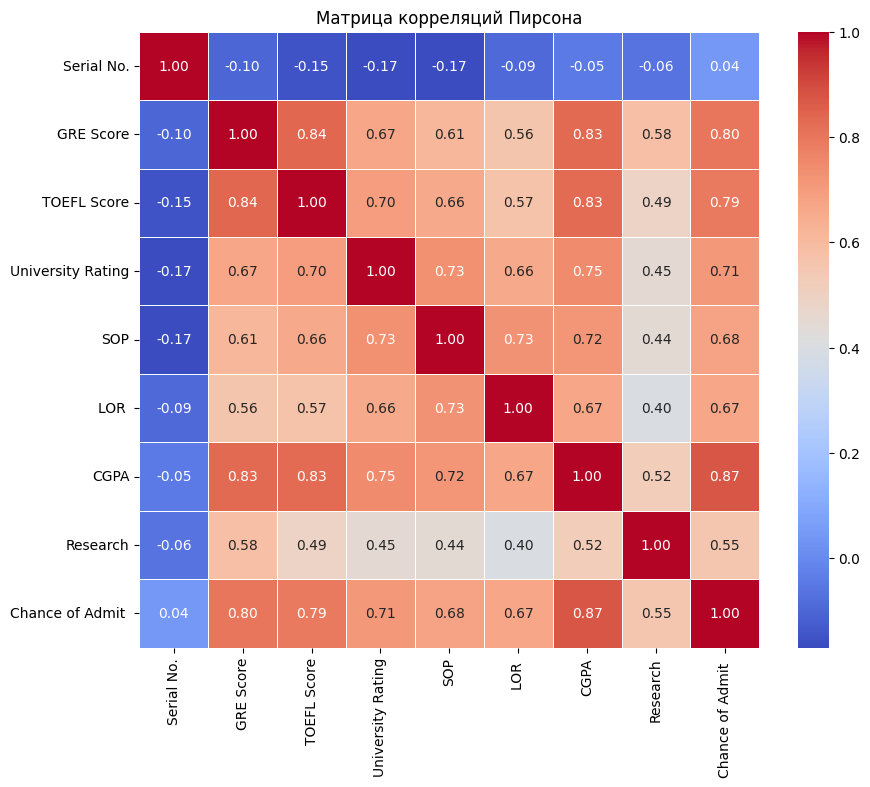


Корреляции с целевой переменной 'Chance of Admit ':
Chance of Admit      1.000000
CGPA                 0.873289
GRE Score            0.802610
TOEFL Score          0.791594
University Rating    0.711250
SOP                  0.675732
LOR                  0.669889
Research             0.553202
Serial No.           0.042336
Name: Chance of Admit , dtype: float64


In [5]:
# Исключаем нечисловые колонки (если есть)
# В этом датасете все колонки числовые

# Матрица корреляций Пирсона
corr_matrix = df_clean.corr(method='pearson')

# Визуализация тепловой карты
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляций Пирсона')
plt.show()

# Наиболее сильные корреляции с целевой переменной (предположим, что целевая переменная – 'Chance of Admit')
# В датасете последняя колонка обычно 'Chance of Admit '
target_col = [col for col in df_clean.columns if 'Chance' in col or 'Admit' in col][0]

print(f"\nКорреляции с целевой переменной '{target_col}':")
corr_with_target = corr_matrix[target_col].sort_values(ascending=False)
print(corr_with_target)

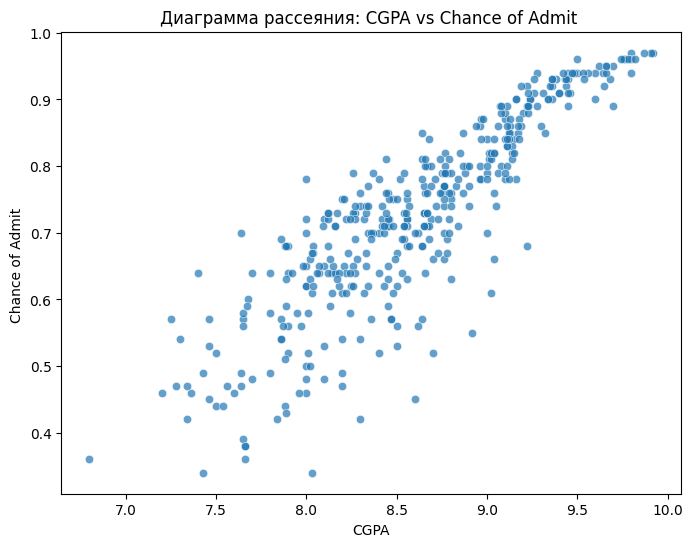

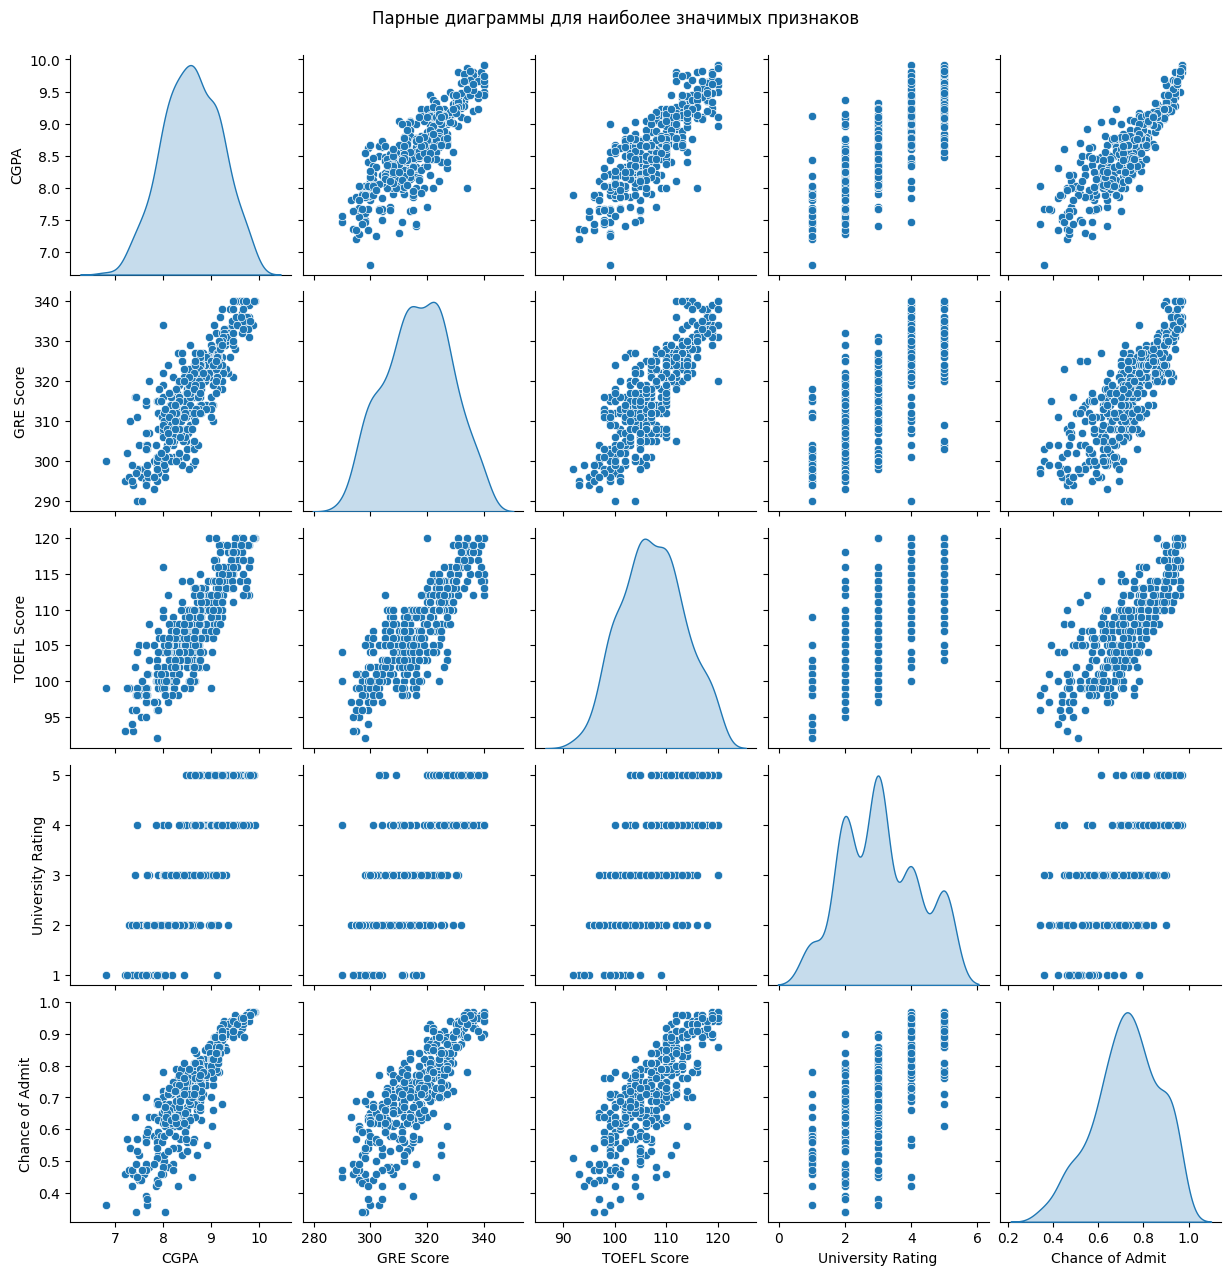

In [6]:
# Диаграмма рассеяния для пары наиболее коррелирующих признаков
# Находим признак с максимальной корреляцией (исключая саму целевую)
top_feature = corr_with_target.index[1]  # первый после самой целевой

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x=top_feature, y=target_col, alpha=0.7)
plt.title(f'Диаграмма рассеяния: {top_feature} vs {target_col}')
plt.xlabel(top_feature)
plt.ylabel(target_col)
plt.show()

# Парные диаграммы (pairplot) для наиболее значимых признаков
# Выбираем топ-4 признака по корреляции с целевой переменной
top_features = corr_with_target.index[1:5].tolist() + [target_col]

sns.pairplot(df_clean[top_features], diag_kind='kde')
plt.suptitle('Парные диаграммы для наиболее значимых признаков', y=1.02)
plt.show()

In [7]:
# Анализ мультиколлинеарности
# Высокая корреляция между признаками-предикторами (>0.8) может быть проблемой

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("Пары признаков с высокой корреляцией (>0.8):")
for pair in high_corr_pairs:
    print(f"  {pair[0]} — {pair[1]}: {pair[2]:.2f}")

Пары признаков с высокой корреляцией (>0.8):
  GRE Score — TOEFL Score: 0.84
  GRE Score — CGPA: 0.83
  GRE Score — Chance of Admit : 0.80
  TOEFL Score — CGPA: 0.83
  CGPA — Chance of Admit : 0.87
